<h1 id="Lecture-10:-Trees,-ensembles,-clustering,-and-PCA">Lecture 10: Trees, ensembles, clustering, and PCA</h1><p>Trees partition feature space. Ensembles aggregate many unstable learners. Unsupervised methods impose a structure through representation, distance, or variance. Each result needs validation before it informs an action.</p>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.datasets import load_wine, make_moons
from sklearn.decomposition import PCA
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import DecisionBoundaryDisplay, permutation_importance
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

TEAL, MINT, GOLD, CORAL, INK = "#005F73", "#0A9396", "#EE9B00", "#BB3E03", "#1D3557"
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.titleweight": "bold"})
wine = load_wine(as_frame=True)
X, y = wine.data, wine.target

<h2 id="Begin-with-the-records">Begin with the records</h2><p>Each row is one wine sample measured on several chemical properties. Before a tree partitions the plane or a clustering algorithm groups points, inspect the measured values and their spread. Later visual boundaries and clusters are summaries imposed on these raw records.</p>

In [2]:
wine.frame[["alcohol", "color_intensity", "proline", "target"]].head(10)

,alcohol,color_intensity,proline,target
0,14.23,5.64,1065.0,0
1,13.20,4.38,1050.0,0
2,13.16,5.68,1185.0,0
3,14.37,7.80,1480.0,0
4,13.24,4.32,735.0,0
5,14.20,6.75,1450.0,0
6,14.39,5.25,1290.0,0
7,14.06,5.05,1295.0,0
8,14.83,5.20,1045.0,0
9,13.86,7.22,1045.0,0


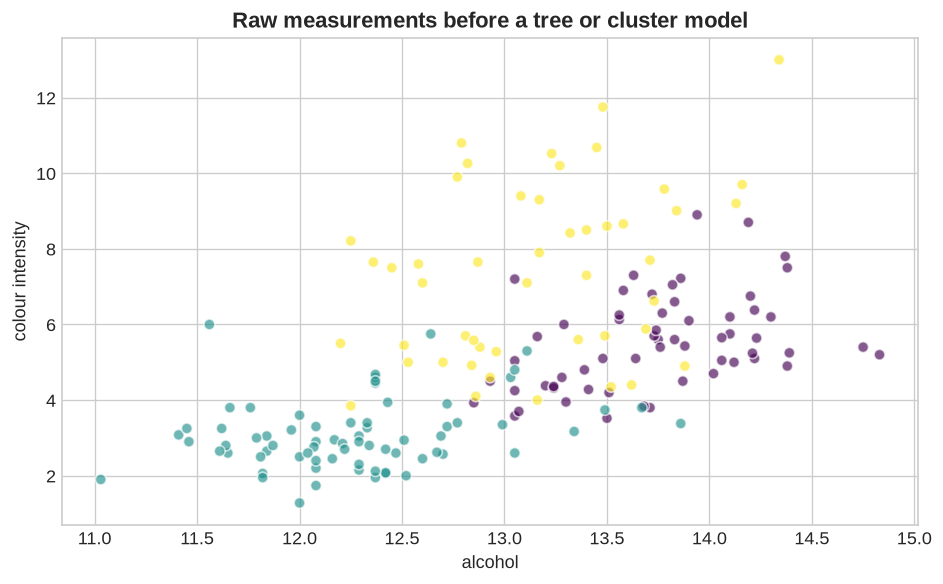

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X.alcohol, X.color_intensity, c=y, cmap="viridis", alpha=.65, edgecolor="white", s=42)
ax.set(title="Raw measurements before a tree or cluster model", xlabel="alcohol", ylabel="colour intensity")
plt.tight_layout()

<h2 id="1.-Tree-partitions-and-impurity">1. Tree partitions and impurity</h2><p>A classification tree recursively asks a feature question such as $x_j\leq s$. It chooses the split with the largest weighted impurity reduction.</p>
<p>$$Gini=1-\sum_k p_k^2, \qquad \Delta I=I(parent)-\frac{n_L}{n}I(L)-\frac{n_R}{n}I(R).$$</p>

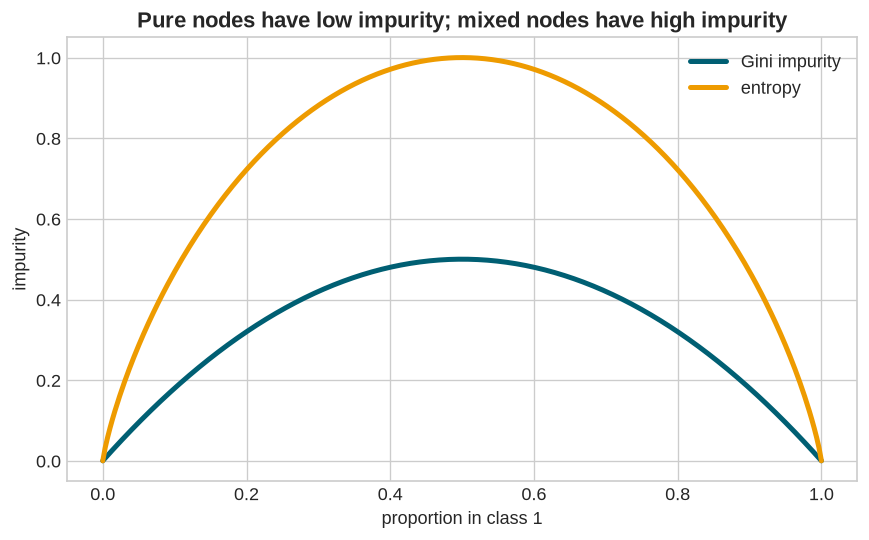

In [4]:
p = np.linspace(0, 1, 300)
gini = 1 - p**2 - (1-p)**2
entropy = -(np.where(p > 0, p*np.log2(np.maximum(p, 1e-10)), 0) + np.where(p < 1, (1-p)*np.log2(np.maximum(1-p, 1e-10)), 0))
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(p, gini, c=TEAL, lw=3, label="Gini impurity")
ax.plot(p, entropy, c=GOLD, lw=3, label="entropy")
ax.set(xlabel="proportion in class 1", ylabel="impurity", title="Pure nodes have low impurity; mixed nodes have high impurity")
ax.legend(); plt.show()

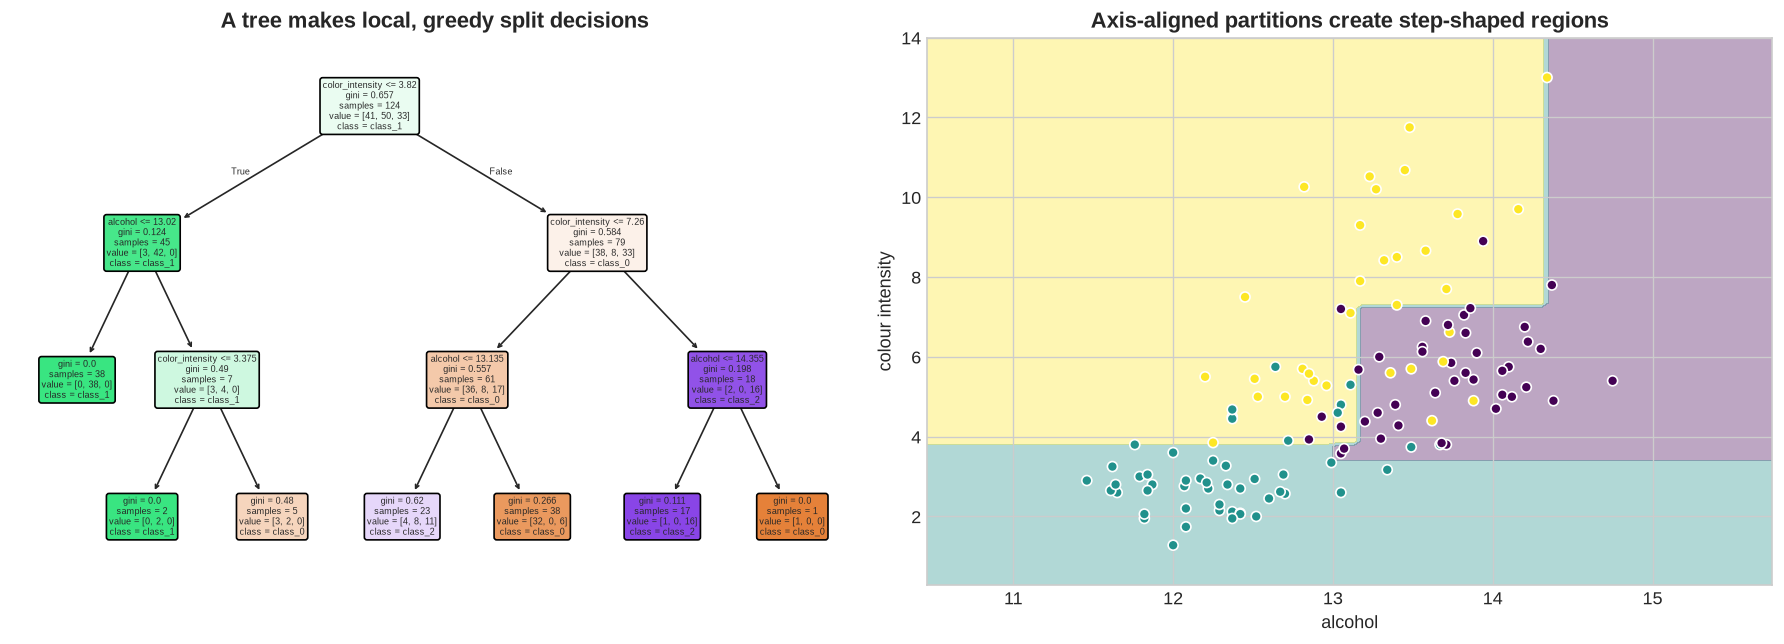

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=.30, random_state=301)
tree_features = ["alcohol", "color_intensity"]
tree = DecisionTreeClassifier(max_depth=3, random_state=301).fit(X_train[tree_features], y_train)
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
plot_tree(tree, feature_names=tree_features, class_names=wine.target_names, filled=True, rounded=True, ax=axes[0])
axes[0].set_title("A tree makes local, greedy split decisions")
DecisionBoundaryDisplay.from_estimator(tree, X_train[tree_features], response_method="predict", multiclass_colors="viridis", alpha=.35, ax=axes[1])
axes[1].scatter(X_train.alcohol, X_train.color_intensity, c=y_train, cmap="viridis", edgecolor="white")
axes[1].set(xlabel="alcohol", ylabel="colour intensity", title="Axis-aligned partitions create step-shaped regions")
plt.tight_layout()

<h2 id="2.-Depth,-pruning,-and-overfitting">2. Depth, pruning, and overfitting</h2><p>Deep trees can memorize rare combinations. Depth and minimum-leaf constraints act as pre-pruning; cross-validation chooses complexity from evidence.</p>

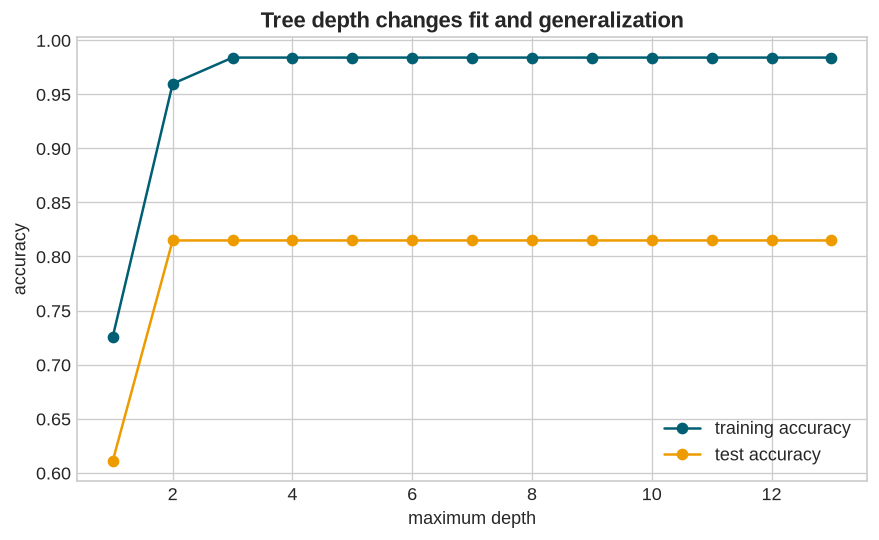

In [6]:
depths = range(1, 14); train_score, test_score = [], []
for depth in depths:
    candidate = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=2, random_state=301).fit(X_train, y_train)
    train_score.append(candidate.score(X_train, y_train)); test_score.append(candidate.score(X_test, y_test))
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(depths, train_score, "o-", c=TEAL, label="training accuracy")
ax.plot(depths, test_score, "o-", c=GOLD, label="test accuracy")
ax.set(xlabel="maximum depth", ylabel="accuracy", title="Tree depth changes fit and generalization")
ax.legend(); plt.show()

<h2 id="3.-Bootstrap-samples,-bagging,-and-random-forests">3. Bootstrap samples, bagging, and random forests</h2><p>A bootstrap sample draws (n) cases with replacement. About 63.2% of unique cases appear in one large sample. Bagging averages many unstable trees. A random forest also restricts candidate features at each split, reducing correlation between trees.</p>

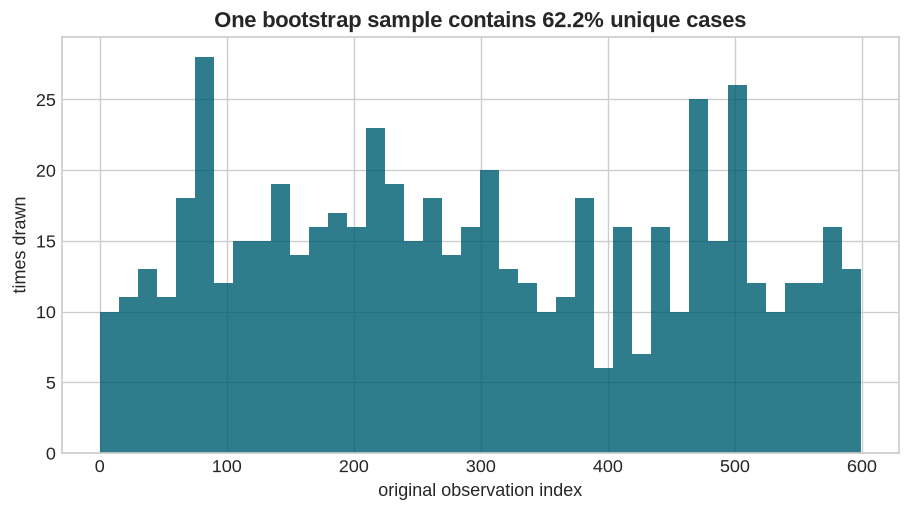

In [7]:
n = 600; draws = np.random.default_rng(10).integers(0, n, size=n)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(draws, bins=40, color=TEAL, alpha=.82)
ax.set(xlabel="original observation index", ylabel="times drawn", title=f"One bootstrap sample contains {len(np.unique(draws))/n:.1%} unique cases")
plt.show()

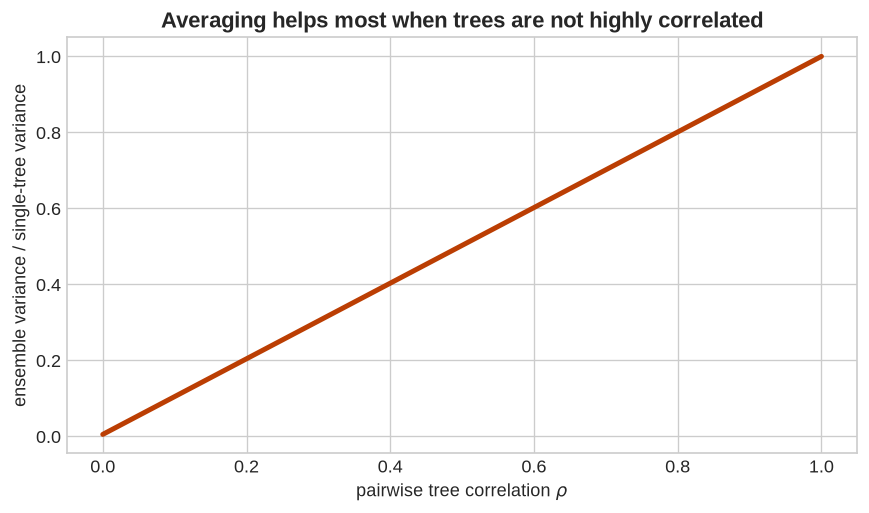

In [8]:
rho = np.linspace(0, 1, 200); B = 200
ensemble_variance = rho + (1-rho)/B
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(rho, ensemble_variance, c=CORAL, lw=3)
ax.set(xlabel="pairwise tree correlation $\\rho$", ylabel="ensemble variance / single-tree variance", title="Averaging helps most when trees are not highly correlated")
plt.show()

In [9]:
forest = RandomForestClassifier(n_estimators=500, min_samples_leaf=2, oob_score=True, random_state=301).fit(X_train, y_train)
boosting = HistGradientBoostingClassifier(learning_rate=.08, max_leaf_nodes=12, random_state=301).fit(X_train, y_train)
print(pd.Series({"forest OOB accuracy": forest.oob_score_, "forest test accuracy": forest.score(X_test, y_test), "boosting test accuracy": boosting.score(X_test, y_test)}).round(3))

forest OOB accuracy       0.984
forest test accuracy      0.981
boosting test accuracy    0.926
dtype: float64


<h2 id="4.-Boosting-learns-from-residual-error">4. Boosting learns from residual error</h2><p>For squared error, the negative gradient is the ordinary residual $y-\hat y$. Gradient boosting fits a small learner to what the current ensemble still misses, then adds a fraction of that learner.</p>

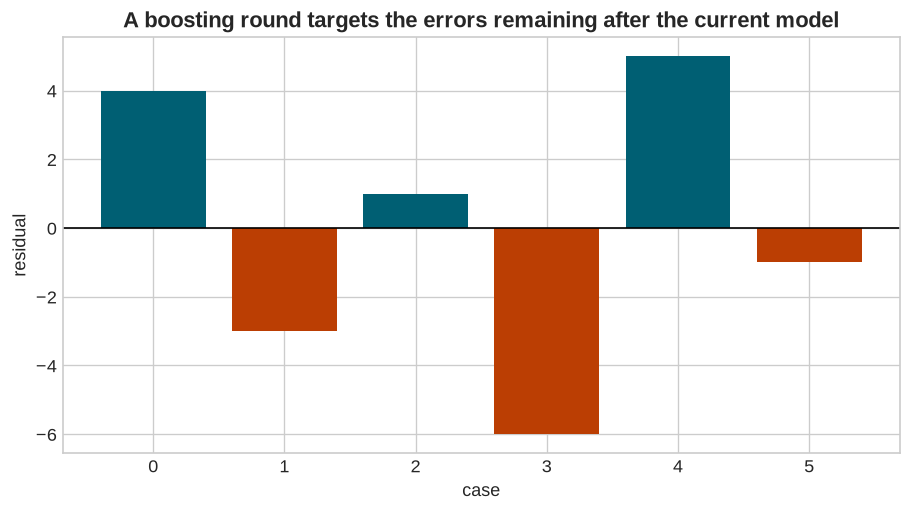

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))
residual = np.array([4, -3, 1, -6, 5, -1])
ax.axhline(0, c="black", lw=1)
ax.bar(np.arange(len(residual)), residual, color=np.where(residual >= 0, TEAL, CORAL))
ax.set(xlabel="case", ylabel="residual", title="A boosting round targets the errors remaining after the current model")
plt.show()

<h2 id="5.-Feature-importance-needs-interpretation">5. Feature importance needs interpretation</h2><p>Impurity importance reflects split gain and can favor features with many possible splits. Permutation importance asks how much validation performance falls after shuffling one feature. Neither gives a causal effect.</p>

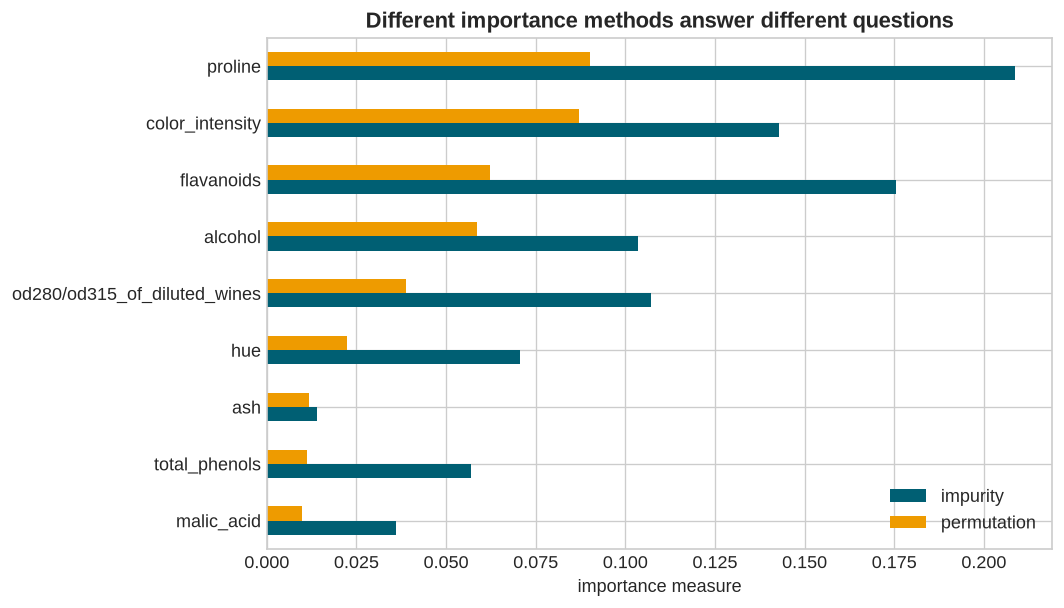

In [11]:
perm = permutation_importance(forest, X_test, y_test, n_repeats=30, random_state=301)
importance = pd.DataFrame({"impurity": forest.feature_importances_, "permutation": perm.importances_mean}, index=X.columns).sort_values("permutation").tail(9)
fig, ax = plt.subplots(figsize=(9, 5.2))
importance.plot(kind="barh", ax=ax, color=[TEAL, GOLD])
ax.set(xlabel="importance measure", title="Different importance methods answer different questions")
plt.tight_layout()

<h2 id="6.-K-means:-assign,-update,-repeat">6. K-means: assign, update, repeat</h2><p>K-means minimizes within-cluster squared distance. It alternates between assigning each point to its nearest centroid and replacing each centroid with the mean of its assigned points. It converges to a local solution, so seeds and stability matter.</p>

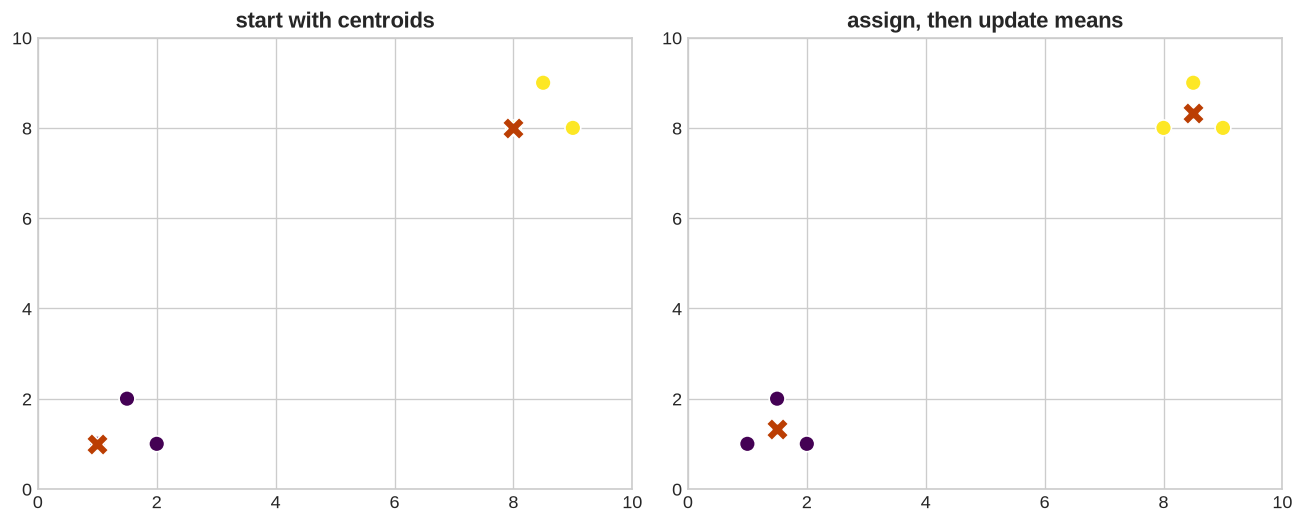

In [12]:
points = np.array([[1,1], [2,1], [1.5,2], [8,8], [9,8], [8.5,9]])
initial = np.array([[1,1], [8,8]])
assignment = ((points[:,None,:]-initial[None,:,:])**2).sum(axis=2).argmin(axis=1)
updated = np.vstack([points[assignment == k].mean(axis=0) for k in range(2)])
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, centroids, title in [(axes[0], initial, "start with centroids"), (axes[1], updated, "assign, then update means")]:
    ax.scatter(points[:,0], points[:,1], c=assignment, cmap="viridis", s=90, edgecolor="white")
    ax.scatter(centroids[:,0], centroids[:,1], marker="X", s=180, c=CORAL, edgecolor="white")
    ax.set(xlim=(0,10), ylim=(0,10), title=title)
plt.tight_layout()

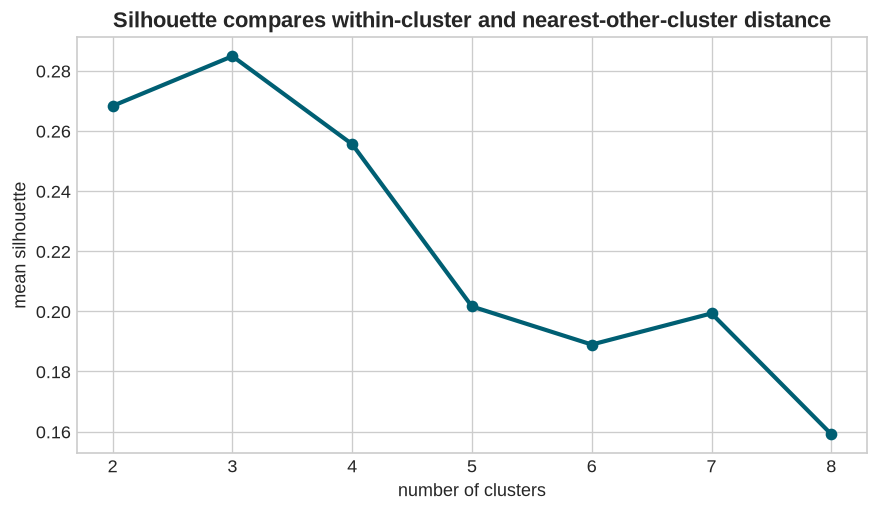

In [13]:
scaled = StandardScaler().fit_transform(X)
scores = []
for k in range(2, 9):
    labels = KMeans(n_clusters=k, n_init=30, random_state=301).fit_predict(scaled)
    scores.append((k, silhouette_score(scaled, labels)))
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(*zip(*scores), "o-", c=TEAL, lw=2.5)
ax.set(xlabel="number of clusters", ylabel="mean silhouette", title="Silhouette compares within-cluster and nearest-other-cluster distance")
plt.show()

<h2 id="7.-Hierarchy,-density,-and-cluster-boundaries">7. Hierarchy, density, and cluster boundaries</h2><p>Hierarchical clustering records a merge history. DBSCAN finds dense regions and labels some points as noise. The representation and parameters create the output: no algorithm discovers a natural customer type by default.</p>

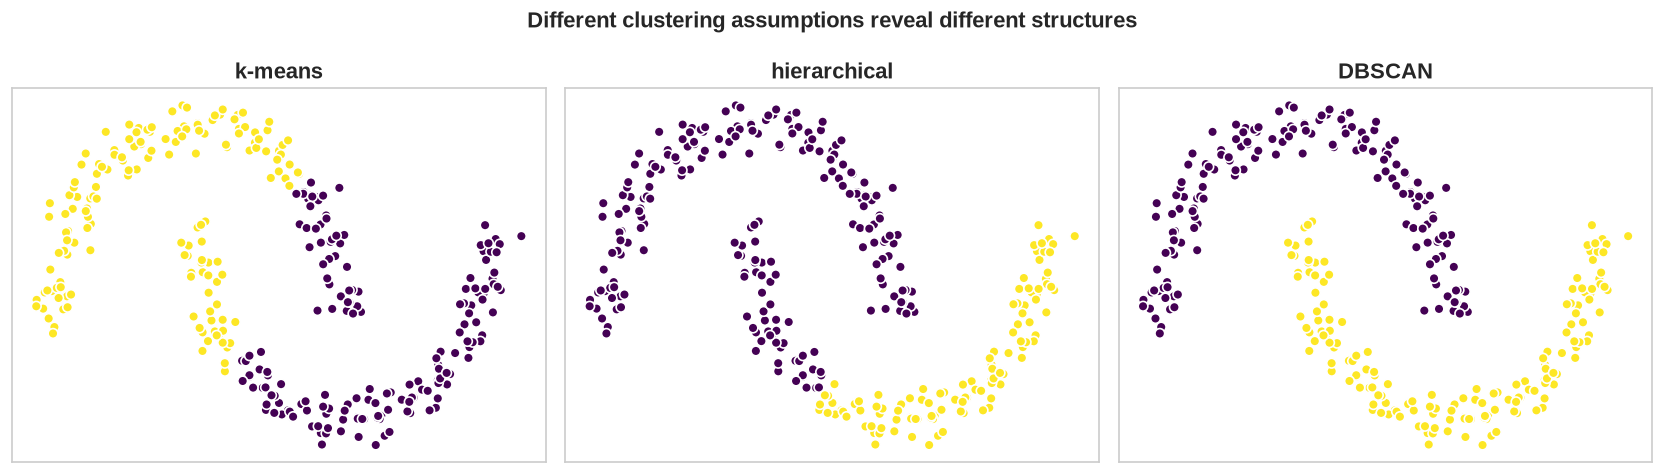

In [14]:
moons, _ = make_moons(n_samples=330, noise=.07, random_state=301)
methods = {
    "k-means": KMeans(n_clusters=2, n_init=30, random_state=301).fit_predict(moons),
    "hierarchical": AgglomerativeClustering(n_clusters=2, linkage="ward").fit_predict(moons),
    "DBSCAN": DBSCAN(eps=.18, min_samples=6).fit_predict(moons),
}
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, labels) in zip(axes, methods.items()):
    ax.scatter(moons[:,0], moons[:,1], c=labels, cmap="viridis", s=34, edgecolor="white")
    ax.set(title=name, xticks=[], yticks=[])
fig.suptitle("Different clustering assumptions reveal different structures", weight="bold")
plt.tight_layout()

<h2 id="8.-PCA:-variance,-projection,-and-reconstruction">8. PCA: variance, projection, and reconstruction</h2><p>PCA rotates centered data to orthogonal directions of maximum variance. Explained variance measures compression, not predictive value, fairness, or causal importance.</p>

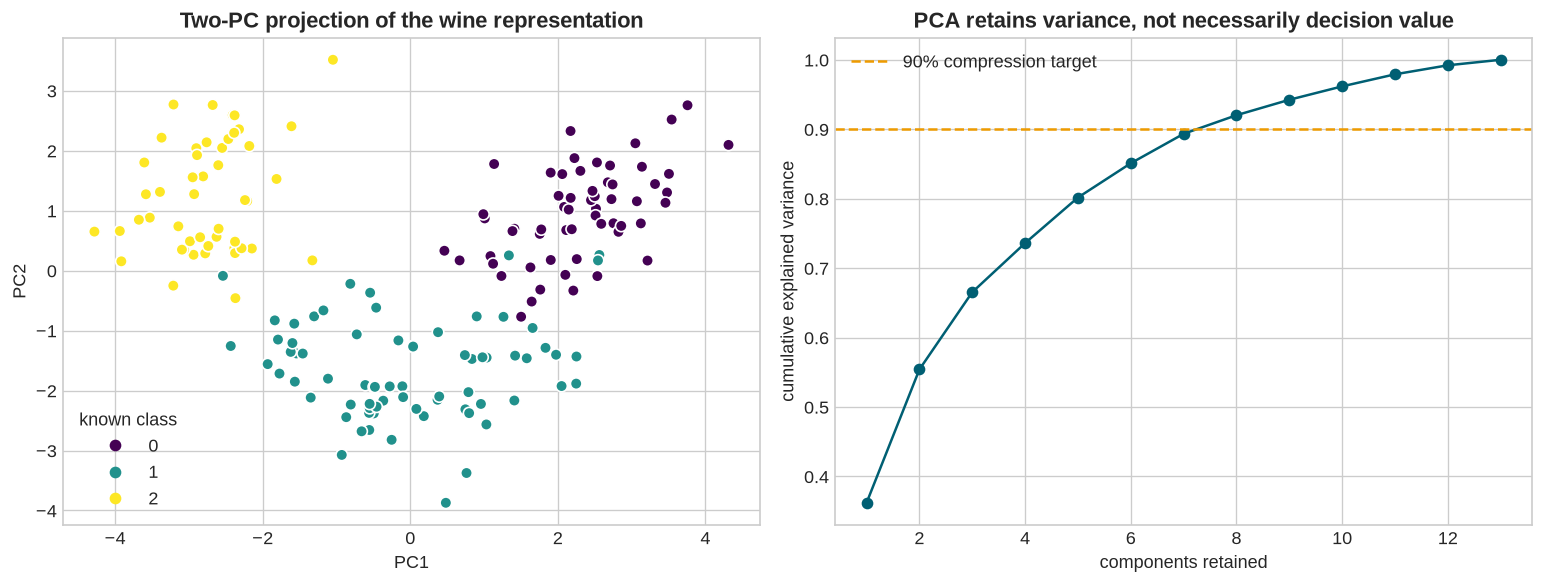

In [15]:
pca = PCA().fit(scaled)
projected = pca.transform(scaled)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
scatter = axes[0].scatter(projected[:,0], projected[:,1], c=y, cmap="viridis", s=48, edgecolor="white")
axes[0].set(xlabel="PC1", ylabel="PC2", title="Two-PC projection of the wine representation")
axes[0].legend(*scatter.legend_elements(), title="known class")
axes[1].plot(np.arange(1, len(pca.explained_variance_ratio_)+1), np.cumsum(pca.explained_variance_ratio_), "o-", c=TEAL)
axes[1].axhline(.90, c=GOLD, ls="--", label="90% compression target")
axes[1].set(xlabel="components retained", ylabel="cumulative explained variance", title="PCA retains variance, not necessarily decision value")
axes[1].legend()
plt.tight_layout()

<h2 id="Check-your-understanding">Check your understanding</h2><ol>
<li>Why can a deeper tree have worse test accuracy even when training accuracy improves?</li>
<li>Why do random forests restrict candidate features at a split?</li>
<li>What does a negative-gradient or residual learner do in boosting?</li>
<li>Why can a high silhouette score still produce an unhelpful segmentation?</li>
<li>What does PCA's explained variance fail to tell you?</li>
</ol>

<h2 id="Applied-modelling-lab:-a-real-dataset-from-raw-records-to-comparison">Applied modelling lab: a real dataset from raw records to comparison</h2><p>The wine dataset contains chemical measurements for individual wines. The left plot retains the raw observations. The right plot compares a single tree with an ensemble on a held-out set, then links the better model back to the features it used.</p>

In [16]:
wine_raw = load_wine(as_frame=True).frame
wine_raw[["alcohol", "color_intensity", "proline", "target"]].head(8)

,alcohol,color_intensity,proline,target
0,14.23,5.64,1065.0,0
1,13.20,4.38,1050.0,0
2,13.16,5.68,1185.0,0
3,14.37,7.80,1480.0,0
4,13.24,4.32,735.0,0
5,14.20,6.75,1450.0,0
6,14.39,5.25,1290.0,0
7,14.06,5.05,1295.0,0


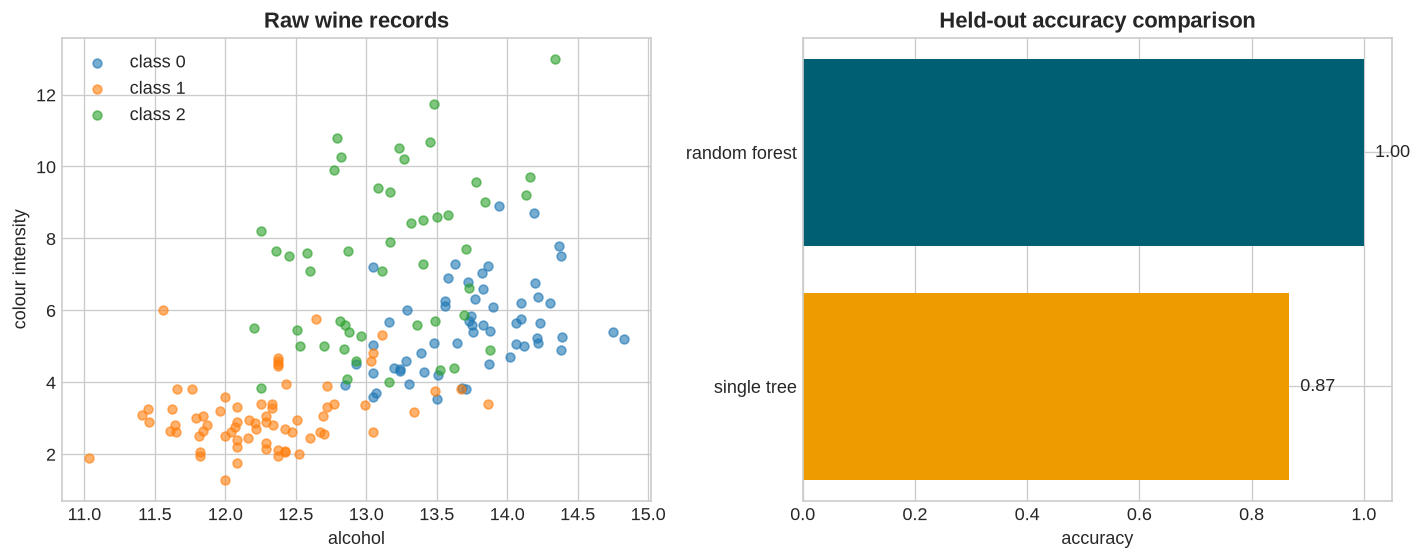

In [17]:
X_train, X_test, y_train, y_test = train_test_split(wine_raw.drop(columns="target"), wine_raw.target, stratify=wine_raw.target, test_size=.25, random_state=301)
single_tree = DecisionTreeClassifier(max_depth=3, random_state=301).fit(X_train, y_train)
forest = RandomForestClassifier(n_estimators=300, max_features="sqrt", random_state=301).fit(X_train, y_train)
importance = pd.Series(forest.feature_importances_, index=X_train.columns).nlargest(6).sort_values()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for target, group in wine_raw.groupby("target"):
    axes[0].scatter(group.alcohol, group.color_intensity, s=28, alpha=.6, label=f"class {target}")
axes[0].set(title="Raw wine records", xlabel="alcohol", ylabel="colour intensity"); axes[0].legend()
scores = pd.Series({"single tree": single_tree.score(X_test, y_test), "random forest": forest.score(X_test, y_test)})
axes[1].barh(scores.index, scores.values, color=[GOLD, TEAL]); axes[1].set(xlim=(0, 1.05), title="Held-out accuracy comparison", xlabel="accuracy")
for i, value in enumerate(scores.values): axes[1].text(value + .02, i, f"{value:.2f}", va="center")
plt.tight_layout()

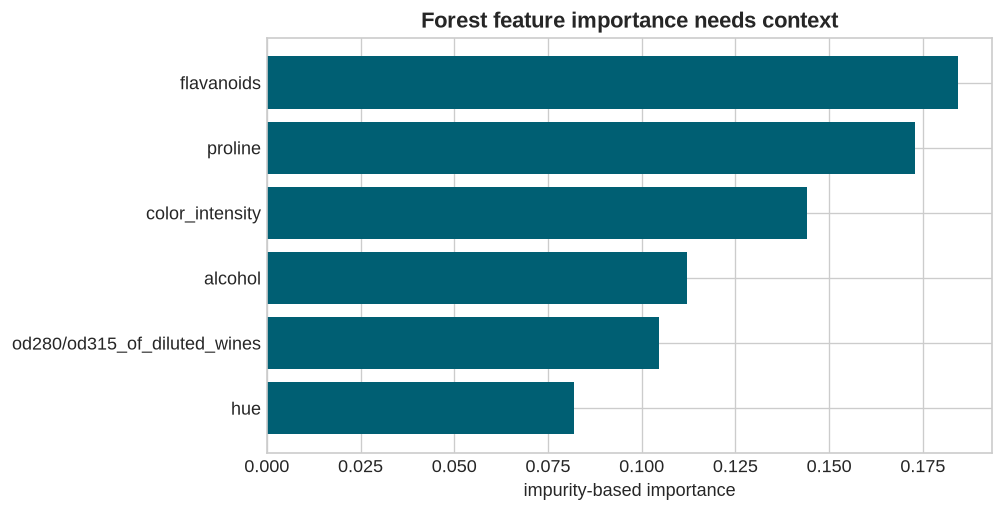

In [18]:
fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.barh(importance.index, importance.values, color=TEAL)
ax.set(title="Forest feature importance needs context", xlabel="impurity-based importance")
plt.tight_layout()

<p>The ensemble comparison answers a prediction question for this split. Feature importance is a model summary, not a causal explanation or a substitute for checking subgroup performance.</p>